In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import scanpy as sc
from matplotlib import rc_context
import anndata as ad
import gc

In [2]:
# suppress future warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
# from statannotations.Annotator import Annotator
sc.set_figure_params(vector_friendly=True, dpi_save=600) 

In [4]:
sns.set_theme(style='white')

In [7]:
df_metrics = pd.read_csv('/home/wu/datb1/AutoExtractSingleCell/01.benchmark_datasets/sample1_text_replacement/replacement_GPTCelltype_DeepSeek.csv', comment='#')
metadata = pd.read_excel('tables/Table S1.xlsx')
metadata.rename(columns={'Dataset No.': 'dataset'}, inplace=True)
df_metrics = df_metrics.join(metadata.set_index('dataset'), on='dataset')

### Similarity

In [8]:
sns.set_theme(style='white')

In [9]:
df_metrics

,dataset,agent,percentage,version,method,n_cells,real_cell_types,predicted_cell_types,average_accuracy,group_accuracy,...,very_rare_accuracy,batch_std,within_batch_var,total_var,batch_effect_ratio,Article,cellxgene Link,Processing Details,Raw Data,Tissue
0,sample1,deepseek,100percent,v1,GPTCelltype,45962,14,14,0.539162,0.507453,...,0.278015,0.016536,0.010614,0.010337,1.026762,Immunophenotyping of COVID-19 and influenza hi...,https://cellxgene.cziscience.com/collections/4...,Start from GSE,GSE149689,blood
1,sample1,deepseek,100percent,v1,scExtract,45962,14,18,0.619738,0.589088,...,0.292013,0.028993,0.021744,0.021867,0.994406,Immunophenotyping of COVID-19 and influenza hi...,https://cellxgene.cziscience.com/collections/4...,Start from GSE,GSE149689,blood
2,sample1,deepseek,100percent,v3,GPTCelltype,46105,14,20,0.547618,0.511055,...,0.453021,0.019386,0.011077,0.011456,0.966962,Immunophenotyping of COVID-19 and influenza hi...,https://cellxgene.cziscience.com/collections/4...,Start from GSE,GSE149689,blood
3,sample1,deepseek,100percent,v3,scExtract,46105,14,15,0.641952,0.629164,...,0.559200,0.029116,0.017698,0.018178,0.973562,Immunophenotyping of COVID-19 and influenza hi...,https://cellxgene.cziscience.com/collections/4...,Start from GSE,GSE149689,blood
4,sample1,claude,35,20percent,GPTCelltype,47437,14,13,0.604847,0.561135,...,NaN,0.025874,0.021948,0.022413,0.979288,Immunophenotyping of COVID-19 and influenza hi...,https://cellxgene.cziscience.com/collections/4...,Start from GSE,GSE149689,blood
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,sample1,claude,35,0percent,scExtract,59176,14,18,0.685648,0.631032,...,NaN,0.030454,0.037984,0.038425,0.988518,Immunophenotyping of COVID-19 and influenza hi...,https://cellxgene.cziscience.com/collections/4...,Start from GSE,GSE149689,blood
68,sample1,claude,35,20percent,GPTCelltype,59572,14,12,0.517331,0.515009,...,NaN,0.022402,0.017841,0.017941,0.994427,Immunophenotyping of COVID-19 and influenza hi...,https://cellxgene.cziscience.com/collections/4...,Start from GSE,GSE149689,blood
69,sample1,claude,35,20percent,scExtract,59572,14,15,0.665053,0.630425,...,NaN,0.043560,0.033510,0.034062,0.983796,Immunophenotyping of COVID-19 and influenza hi...,https://cellxgene.cziscience.com/collections/4...,Start from GSE,GSE149689,blood
70,sample1,claude,35,20percent,GPTCelltype,59176,14,13,0.588189,0.554346,...,NaN,0.021513,0.023399,0.023824,0.982144,Immunophenotyping of COVID-19 and influenza hi...,https://cellxgene.cziscience.com/collections/4...,Start from GSE,GSE149689,blood


In [10]:
df_metrics['percentage'] = df_metrics['percentage'].str.replace('percent', '')

In [11]:
order = ['0', '20', '40', '60', '80', '100']
methods = order

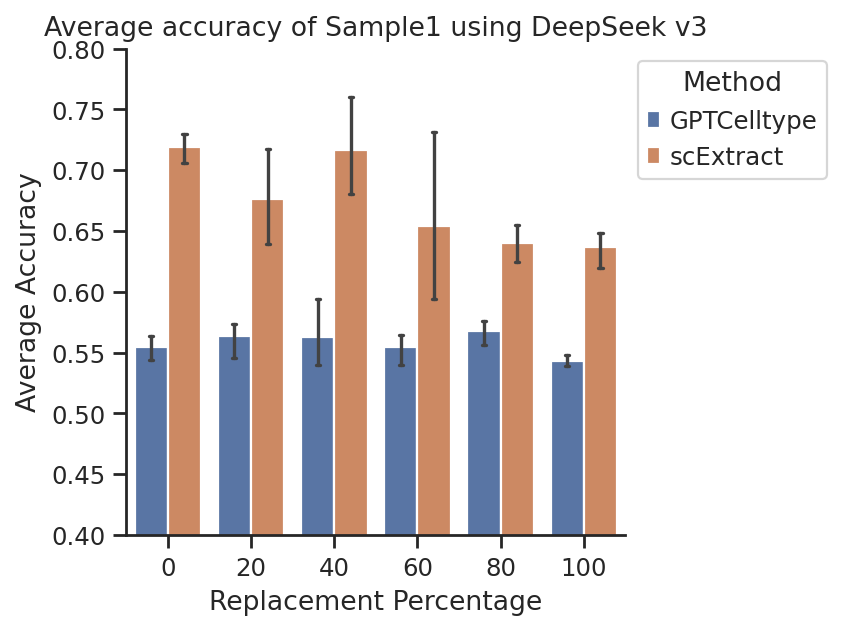

In [12]:
with plt.rc_context({'figure.figsize': [4, 4]}):
    g = sns.barplot(data=df_metrics, x='percentage', y='average_accuracy', order=methods, hue='method', capsize=0.1, errwidth=1.5)
    g.set_ylim(0.4, 0.8)
    # set legend outside
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Method')
    g.set_xlabel('Replacement Percentage')
    g.set_ylabel('Average Accuracy')
    g.yaxis.set_ticks_position('left')
    g.xaxis.set_ticks_position('bottom')
    g.set_title('Average accuracy of Sample1 using DeepSeek v3')
    sns.despine()
    plt.savefig('/home/wu/datb1/AutoExtractSingleCell/scExtract_reproduce/figures_revision/article_quality/average_accuracy_sample1_deepseek.pdf', bbox_inches='tight')

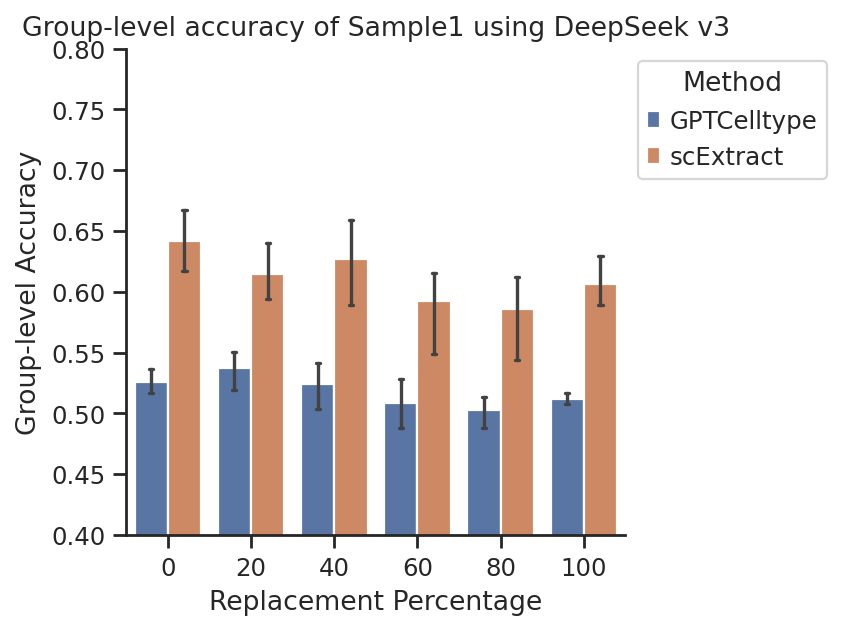

In [13]:
with plt.rc_context({'figure.figsize': [4, 4]}):
    g = sns.barplot(data=df_metrics, x='percentage', y='group_accuracy', order=methods, hue='method', capsize=0.1, errwidth=1.5)
    g.set_ylim(0.4, 0.8)
    # set legend outside
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Method')
    g.set_xlabel('Replacement Percentage')
    g.set_ylabel('Group-level Accuracy')
    g.yaxis.set_ticks_position('left')
    g.xaxis.set_ticks_position('bottom')
    g.set_title('Group-level accuracy of Sample1 using DeepSeek v3')
    sns.despine()
    plt.savefig('/home/wu/datb1/AutoExtractSingleCell/scExtract_reproduce/figures_revision/article_quality/group_accuracy_sample1_deepseek.pdf', bbox_inches='tight')

In [14]:
df_metrics = pd.read_csv('/home/wu/datb1/AutoExtractSingleCell/01.benchmark_datasets/sample1_text_replacement/replacement_GPTCelltype_Claude35.csv', comment='#')
metadata = pd.read_excel('tables/Table S1.xlsx')
metadata.rename(columns={'Dataset No.': 'dataset'}, inplace=True)
df_metrics = df_metrics.join(metadata.set_index('dataset'), on='dataset')
df_metrics['percentage'] = df_metrics['percentage'].str.replace('percent', '')

In [15]:
df_metrics

,dataset,agent,percentage,version,method,n_cells,real_cell_types,predicted_cell_types,average_accuracy,group_accuracy,...,batch_std,within_batch_var,total_var,batch_effect_ratio,very_rare_accuracy,Article,cellxgene Link,Processing Details,Raw Data,Tissue
0,sample1,claude35,20,v1,GPTCelltype,47437,14,13,0.604847,0.561135,...,0.025874,0.021948,0.022413,0.979288,NaN,Immunophenotyping of COVID-19 and influenza hi...,https://cellxgene.cziscience.com/collections/4...,Start from GSE,GSE149689,blood
1,sample1,claude35,20,v1,scExtract,47437,14,14,0.766382,0.696210,...,0.040546,0.030312,0.031047,0.976321,NaN,Immunophenotyping of COVID-19 and influenza hi...,https://cellxgene.cziscience.com/collections/4...,Start from GSE,GSE149689,blood
2,sample1,claude35,40,v2,GPTCelltype,56528,14,13,0.566759,0.543338,...,0.022375,0.015544,0.015365,1.011659,0.519216,Immunophenotyping of COVID-19 and influenza hi...,https://cellxgene.cziscience.com/collections/4...,Start from GSE,GSE149689,blood
3,sample1,claude35,40,v2,scExtract,56528,14,15,0.704381,0.646352,...,0.035630,0.038159,0.038600,0.988574,0.641885,Immunophenotyping of COVID-19 and influenza hi...,https://cellxgene.cziscience.com/collections/4...,Start from GSE,GSE149689,blood
4,sample1,claude35,80,v1,GPTCelltype,56528,14,15,0.621919,0.541130,...,0.026558,0.016321,0.016301,1.001206,0.462675,Immunophenotyping of COVID-19 and influenza hi...,https://cellxgene.cziscience.com/collections/4...,Start from GSE,GSE149689,blood
5,sample1,claude35,80,v1,scExtract,56528,14,17,0.662129,0.601392,...,0.025738,0.016406,0.016128,1.017261,0.632279,Immunophenotyping of COVID-19 and influenza hi...,https://cellxgene.cziscience.com/collections/4...,Start from GSE,GSE149689,blood
6,sample1,claude35,100,v1,GPTCelltype,45962,14,12,0.620390,0.559068,...,0.023831,0.010321,0.009590,1.076247,0.267076,Immunophenotyping of COVID-19 and influenza hi...,https://cellxgene.cziscience.com/collections/4...,Start from GSE,GSE149689,blood
7,sample1,claude35,100,v1,scExtract,45962,14,14,0.571037,0.570501,...,0.025719,0.016101,0.016213,0.993127,0.314327,Immunophenotyping of COVID-19 and influenza hi...,https://cellxgene.cziscience.com/collections/4...,Start from GSE,GSE149689,blood
8,sample1,claude35,0,v1,GPTCelltype,59176,14,13,0.573119,0.546841,...,0.023015,0.018943,0.019205,0.986360,NaN,Immunophenotyping of COVID-19 and influenza hi...,https://cellxgene.cziscience.com/collections/4...,Start from GSE,GSE149689,blood
9,sample1,claude35,0,v1,scExtract,59176,14,15,0.681339,0.625070,...,0.037535,0.044792,0.045569,0.982947,NaN,Immunophenotyping of COVID-19 and influenza hi...,https://cellxgene.cziscience.com/collections/4...,Start from GSE,GSE149689,blood


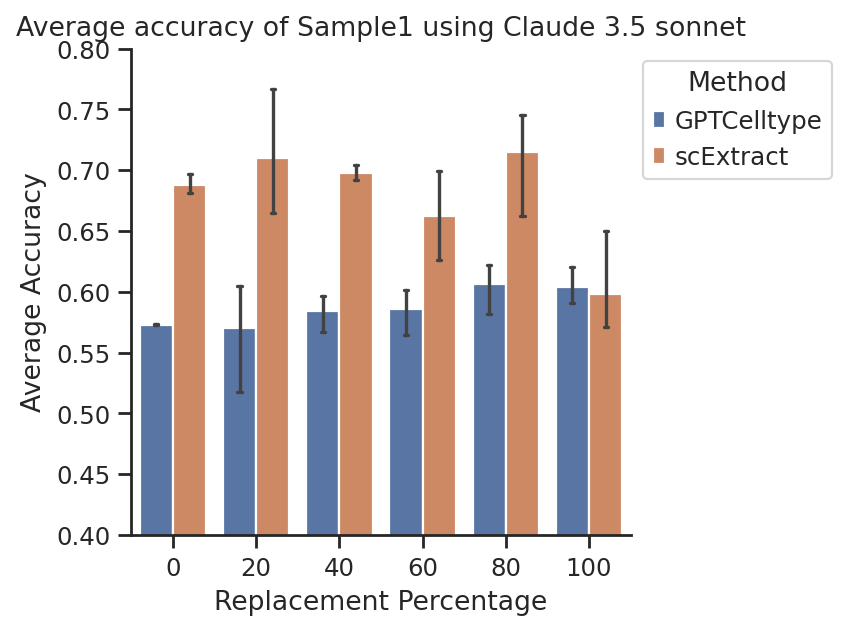

In [16]:
with plt.rc_context({'figure.figsize': [4, 4]}):
    g = sns.barplot(data=df_metrics, x='percentage', y='average_accuracy', order=methods, hue='method', capsize=0.1, errwidth=1.5)
    g.set_ylim(0.4, 0.8)
    # set legend outside
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Method')
    g.set_xlabel('Replacement Percentage')
    g.set_ylabel('Average Accuracy')
    g.yaxis.set_ticks_position('left')
    g.xaxis.set_ticks_position('bottom')
    g.set_title('Average accuracy of Sample1 using Claude 3.5 sonnet')
    sns.despine()
    plt.savefig('/home/wu/datb1/AutoExtractSingleCell/scExtract_reproduce/figures_revision/article_quality/average_accuracy_sample1_claude.pdf', bbox_inches='tight')

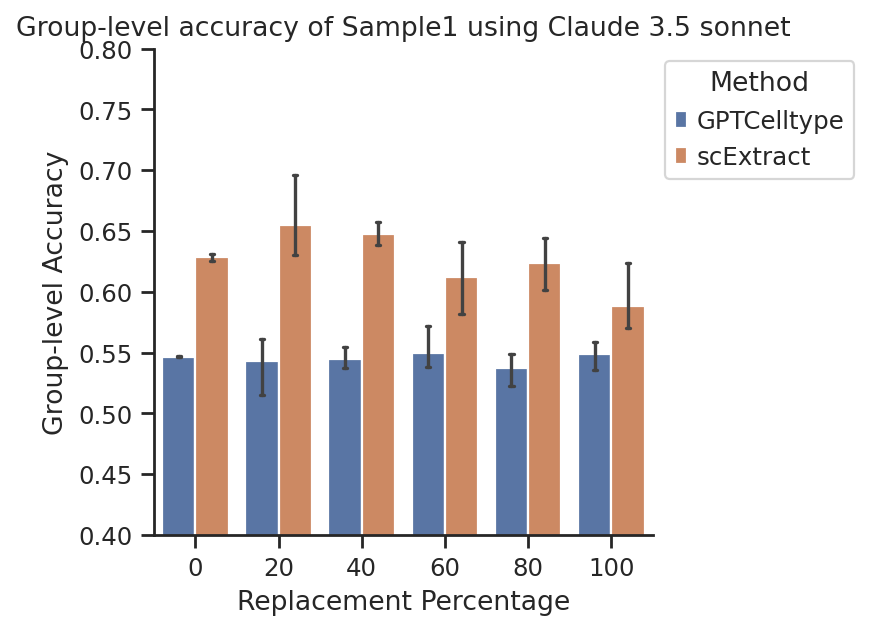

In [17]:
with plt.rc_context({'figure.figsize': [4, 4]}):
    g = sns.barplot(data=df_metrics, x='percentage', y='group_accuracy', order=methods, hue='method', capsize=0.1, errwidth=1.5)
    g.set_ylim(0.4, 0.8)
    # set legend outside
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Method')
    g.set_xlabel('Replacement Percentage')
    g.set_ylabel('Group-level Accuracy')
    g.yaxis.set_ticks_position('left')
    g.xaxis.set_ticks_position('bottom')
    g.set_title('Group-level accuracy of Sample1 using Claude 3.5 sonnet')
    sns.despine()
    plt.savefig('/home/wu/datb1/AutoExtractSingleCell/scExtract_reproduce/figures_revision/article_quality/group_accuracy_sample1_claude.pdf', bbox_inches='tight')